## This analysis seeks to answer the hypothesis: How much will we sell in the coming days?

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
        .appName("Sales_Prediction") \
        .config(
        "spark.jars.packages",
        "org.postgresql:postgresql:42.7.3") \
        .getOrCreate()

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")

try:
    query="""
    (select
        order_purchase_timestamp::date as order_day,
        sum(price) as revenue
    from
        analytics.fact_orders
        where order_purchase_timestamp is not null
     group by order_day  
     order by order_day) as Revenue_query
     """
     
    sales_df = spark.read.format("jdbc") \
        .option("url", f"jdbc:postgresql://{host}:{port}/{database}") \
        .option("dbtable", query) \
        .option("user", user) \
        .option("password", password) \
        .option("driver", "org.postgresql.Driver") \
        .load()
    
    sales_df.show(5)
    
except Exception as e:
    print(f"The error is detailed: {e}")

+----------+--------------------+
| order_day|             revenue|
+----------+--------------------+
|2016-09-04|72.89000000000000...|
|2016-09-05|59.50000000000000...|
|2016-09-15|134.9700000000000...|
|2016-10-02|100.0000000000000...|
|2016-10-03|463.4800000000000...|
+----------+--------------------+
only showing top 5 rows


In [3]:
import pandas as pd
sales_pd = sales_df.toPandas()
sales_pd["order_day"] = pd.to_datetime(sales_pd["order_day"])
sales_pd.set_index('order_day', inplace=True)
sales_pd["revenue"] = pd.to_numeric(sales_pd["revenue"])
sales_pd = sales_pd.sort_values("order_day")
sales_pd.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 616 entries, 2016-09-04 to 2018-09-03
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   revenue  616 non-null    float64
dtypes: float64(1)
memory usage: 9.6 KB


In [4]:
sales_pd.describe()

,revenue
count,616.000000
mean,22064.356656
std,12594.027039
min,10.900000
25%,13018.205000
50%,20511.455000
75%,29591.957500
max,152653.740000


#### Weekly Sales Trend

Text(0, 0.5, 'Weekly_revenue')

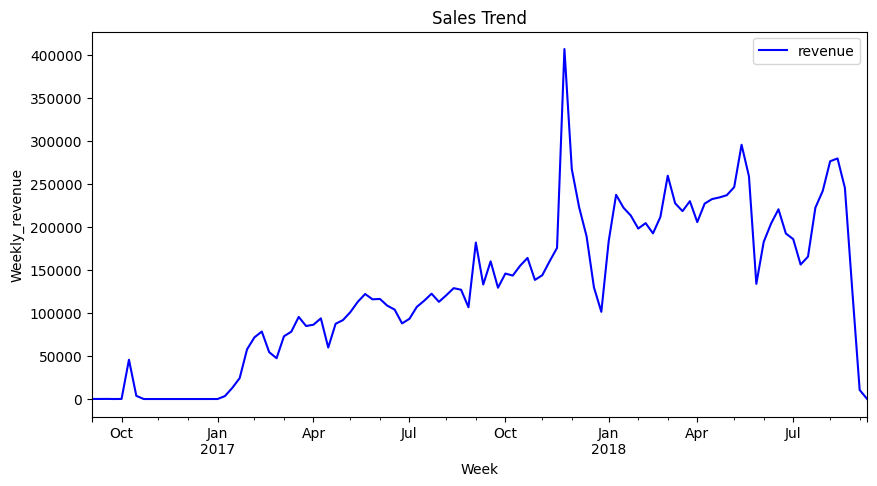

In [5]:
weekly_sales = sales_pd.resample("W").sum()
axis = weekly_sales.plot(figsize=(10,5), color='blue')
axis.set_title("Sales Trend")
axis.set_xlabel("Week")
axis.set_ylabel("Weekly_revenue")

#### Distribution of Sales Data

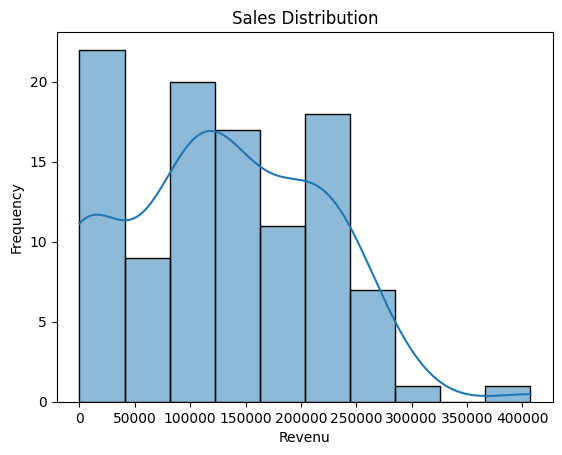

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(weekly_sales["revenue"], bins=10, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Revenu")
plt.ylabel("Frequency")
plt.show()

#### Outliers

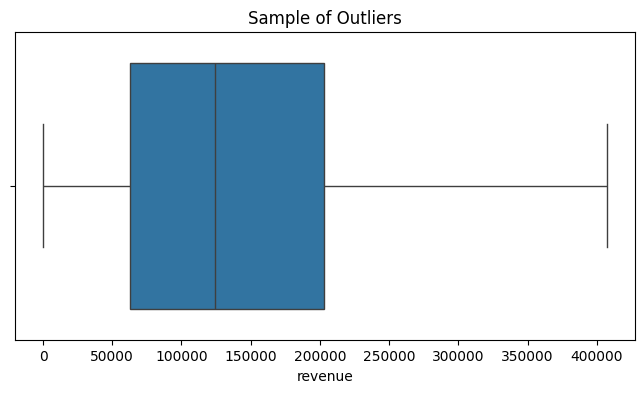

In [7]:
f, ax = plt.subplots(figsize=(8,4))

sns.boxplot(
    x="revenue",
    data=weekly_sales
)

plt.title("Sample of Outliers")

plt.show()

## Baseline Model

#### Moving Average

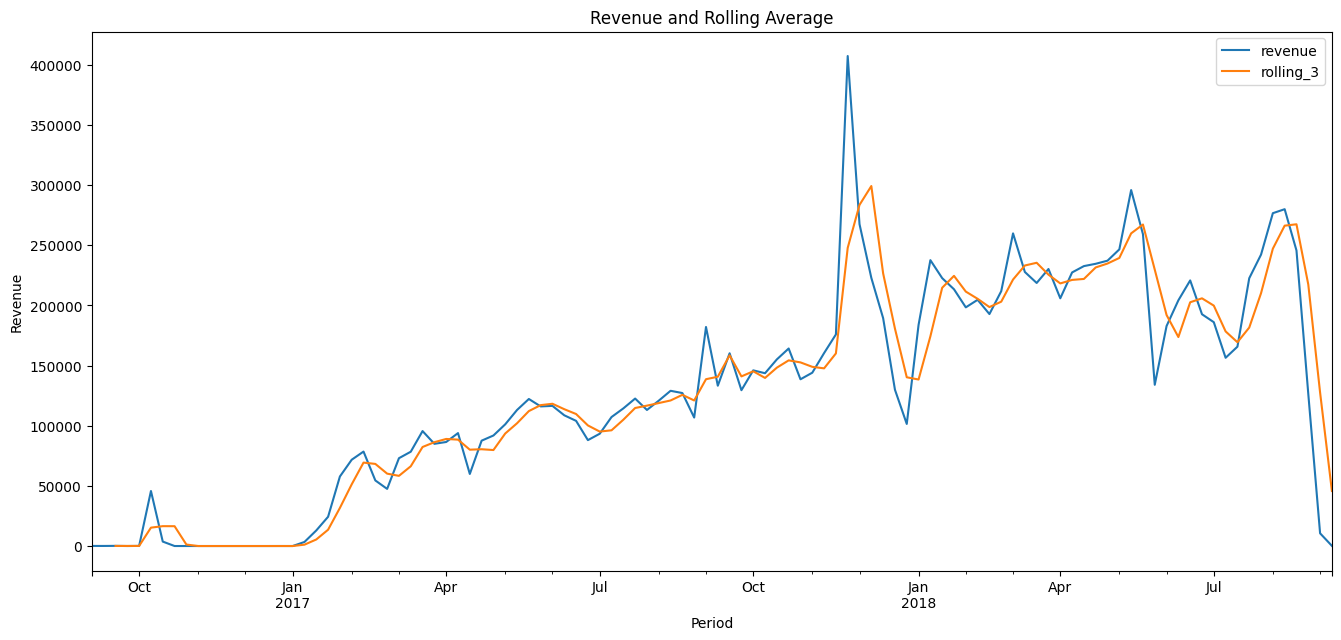

In [9]:
weekly_sales["rolling_3"] = (weekly_sales["revenue"].rolling(window=3).mean())

weekly_sales[["revenue", "rolling_3"]].plot(figsize=(16,7))
plt.title("Revenue and Rolling Average")
plt.xlabel("Period")
plt.ylabel("Revenue")

plt.show()

#### Exponential Smoothing

In [10]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

exp_model = ExponentialSmoothing(weekly_sales["revenue"]).fit()
weekly_sales["exp_model"] = exp_model.fittedvalues

#### Holt Linear Trend

In [11]:
from statsmodels.tsa.holtwinters import Holt

holt_model = Holt(weekly_sales["revenue"]).fit()
weekly_sales["holt_model"] = holt_model.fittedvalues

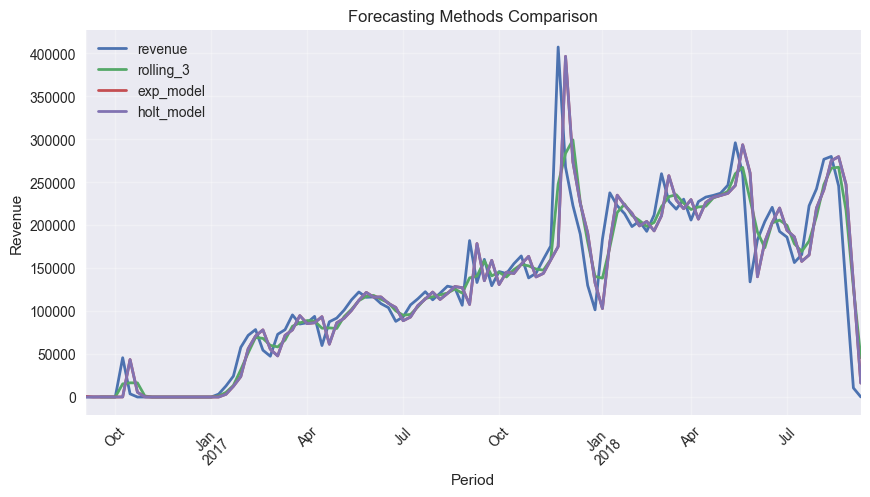

In [12]:
plt.style.use("seaborn-v0_8")
weekly_sales[["revenue", "rolling_3", "exp_model", "holt_model"]].plot(figsize=(10,5),  linewidth=2)
plt.title("Forecasting Methods Comparison")
plt.xlabel("Period")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.legend(loc="upper left")
plt.xticks(rotation=45)

plt.show()

## Training phase Cambiar el numero de train y test

In [13]:
train = weekly_sales.iloc[:-6]
test = weekly_sales.iloc[-6:]

In [14]:
train = weekly_sales.iloc[:-6]
test = weekly_sales.iloc[-6:]

In [15]:
moving_forecast = (train["revenue"].rolling(window=3).mean().iloc[-1])

In [16]:
holt_model = Holt(train["revenue"]).fit()

In [18]:
exp_model = ExponentialSmoothing(train["revenue"]).fit()

## Testing phase

In [ ]:
test["Moving_avg_forecast"] = moving_forecast

In [ ]:
test["Holt_forecast"] = holt_model.forecast(6).values

c:\Professional_project\Virtual_env_project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Professional_project\Virtual_env_project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
test

,total_revenue,rolling_3,exp_model,holt_model,Moving_avg_forecast,Holt_forecast,Expo_smth_forecast
month,,,,,,,
2018-03-01,983213.44,925807.503333,859981.234213,9.460444e+05,846041.08,9.563729e+05,859930.124307
2018-04-01,996647.75,941346.633333,954435.210986,1.016502e+06,846041.08,1.005613e+06,859930.124307
2018-05-01,996517.68,992126.290000,986789.920164,1.054409e+06,846041.08,1.054854e+06,859930.124307
2018-06-01,865124.31,952763.246667,994245.971086,1.070603e+06,846041.08,1.104094e+06,859930.124307
2018-07-01,895507.22,919049.736667,895277.894525,1.002550e+06,846041.08,1.153334e+06,859930.124307
2018-08-01,854686.33,871772.620000,895453.665972,9.906870e+05,846041.08,1.202574e+06,859930.124307


In [ ]:
test["Expo_smth_forecast"] = exp_model.forecast(6).values

c:\Professional_project\Virtual_env_project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Professional_project\Virtual_env_project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
